# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('telco_churn_raw.csv')
print('Shape:', df.shape)
display(df.head())
df.info()


Shape: (2000, 9)


,customerID,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,TechSupport,NumServices,Churn
0,C10000,14,Month-to-month,Bank transfer,42.98,622.98,0,2,0
1,C10001,54,Month-to-month,Electronic check,40.30,2270.22,0,4,0
2,C10002,57,One year,Electronic check,95.40,5264.06,0,7,0
3,C10003,43,Month-to-month,Credit card,27.87,1272.02,1,5,0
4,C10004,48,Month-to-month,Bank transfer,102.60,5126.30,1,4,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      2000 non-null   object 
 1   tenure          2000 non-null   int64  
 2   Contract        2000 non-null   object 
 3   PaymentMethod   2000 non-null   object 
 4   MonthlyCharges  2000 non-null   float64
 5   TotalCharges    1950 non-null   float64
 6   TechSupport     2000 non-null   int64  
 7   NumServices     2000 non-null   int64  
 8   Churn           2000 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 140.8+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,tenure,MonthlyCharges,TotalCharges,TechSupport,NumServices,Churn
count,2000.000000,2000.000000,1950.000000,2000.000000,2000.000000,2000.000000
mean,36.423500,67.671380,2459.280005,0.500000,4.481500,0.163500
std,21.438936,29.479734,1883.349743,0.500125,2.288728,0.369914
min,0.000000,18.010000,0.000000,0.000000,1.000000,0.000000
25%,17.000000,42.777500,969.697500,0.000000,2.000000,0.000000
50%,37.000000,66.855000,1992.180000,0.500000,4.000000,0.000000
75%,55.000000,93.960000,3538.130000,1.000000,7.000000,0.000000
max,72.000000,119.940000,8584.930000,1.000000,8.000000,1.000000


TotalCharges    50
dtype: int64


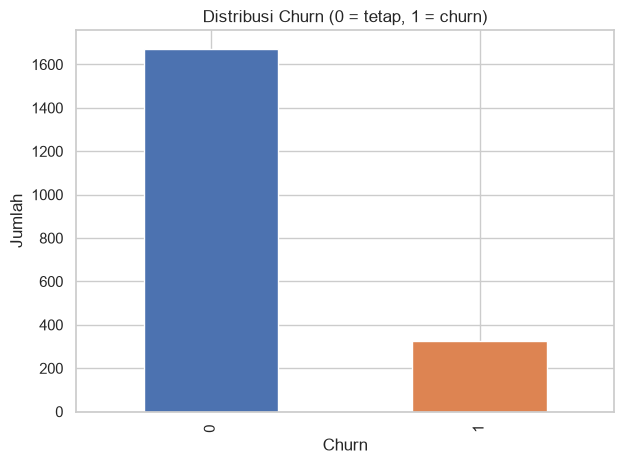

Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


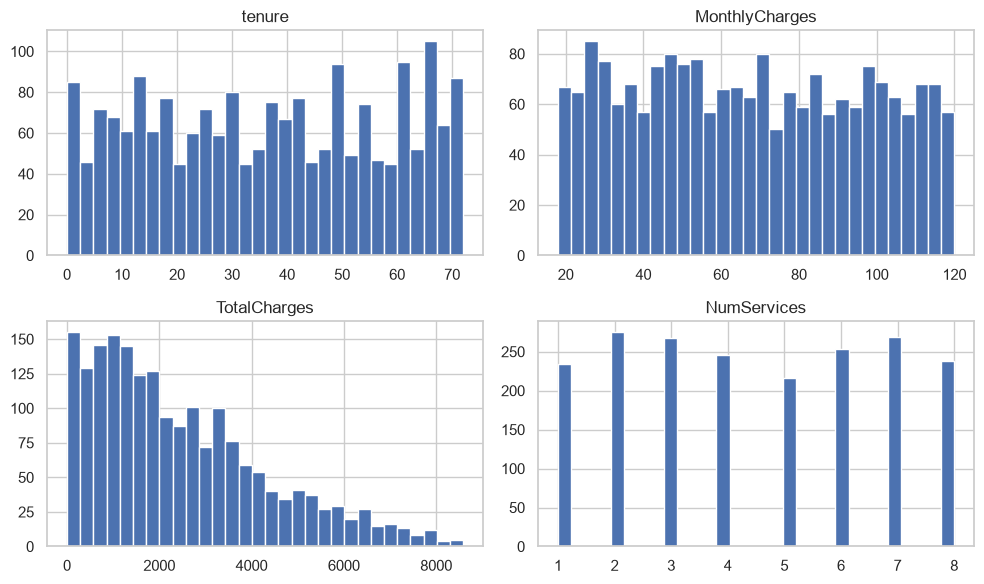

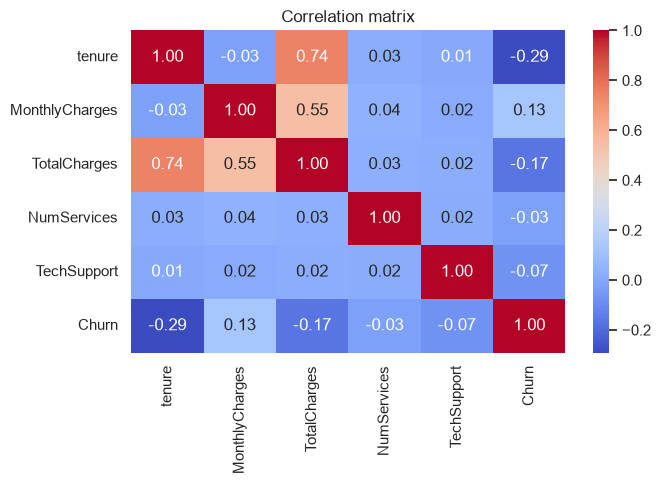

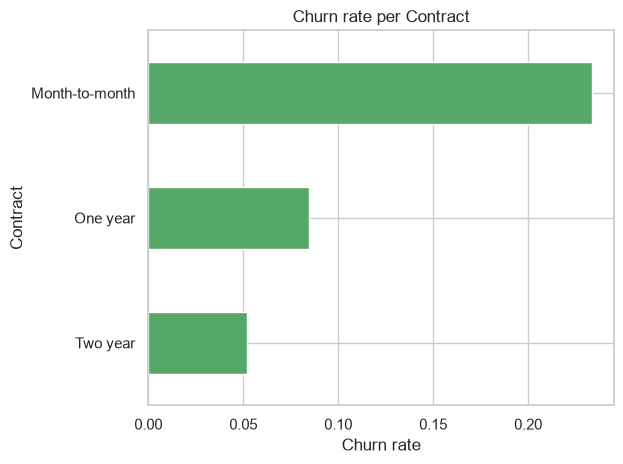

Contract
Two year          0.052055
One year          0.084677
Month-to-month    0.233538
Name: Churn, dtype: float64

In [3]:
# TotalCharges tersimpan sebagai object karena ada nilai kosong -> paksa numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
display(df.describe())

# Missing values
missing = df.isna().sum()
print(missing[missing > 0])

# Distribusi target
ax = df['Churn'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set_title('Distribusi Churn (0 = tetap, 1 = churn)')
ax.set_xlabel('Churn'); ax.set_ylabel('Jumlah')
plt.tight_layout(); plt.show()
print(df['Churn'].value_counts(normalize=True).round(3))

# Distribusi fitur numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
df[num_cols].hist(figsize=(10, 6), bins=30)
plt.tight_layout(); plt.show()

# Korelasi fitur numerik terhadap target
corr = df[num_cols + ['TechSupport', 'Churn']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()

# Churn rate per tipe kontrak (kategori penting)
rate = df.groupby('Contract')['Churn'].mean().sort_values()
rate.plot(kind='barh', color='#55a868')
plt.title('Churn rate per Contract'); plt.xlabel('Churn rate')
plt.tight_layout(); plt.show()
display(rate)

# Temuan EDA:
# - Target sedikit tidak seimbang -> gunakan stratify saat split.
# - TotalCharges punya sebagian nilai kosong -> imputasi median.
# - Kontrak Month-to-month punya churn rate jauh lebih tinggi -> fitur kategorikal penting, perlu encoding.
# - Skala fitur numerik berbeda-beda -> perlu standardisasi.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
import os

TARGET = 'Churn'
NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TechSupport', 'NumServices']
CATEGORICAL = ['Contract', 'PaymentMethod']

X = df.drop(columns=['customerID', TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)

# Imputasi median + standarisasi numerik, one-hot encoding kategorikal
numeric = Pipeline([('impute', SimpleImputer(strategy='median')),
                    ('scale', StandardScaler())])
categorical = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ct = ColumnTransformer([('num', numeric, NUMERIC),
                        ('cat', categorical, CATEGORICAL)])

X_train_t = ct.fit_transform(X_train)
X_test_t = ct.transform(X_test)
cols = list(ct.get_feature_names_out())
X_train_df = pd.DataFrame(X_train_t, columns=cols)
X_test_df = pd.DataFrame(X_test_t, columns=cols)
display(X_train_df.head())

# Simpan dataset hasil preprocessing (siap latih)
os.makedirs('telco_churn_preprocessing', exist_ok=True)
train_out = X_train_df.copy(); train_out[TARGET] = y_train.reset_index(drop=True)
test_out = X_test_df.copy(); test_out[TARGET] = y_test.reset_index(drop=True)
train_out.to_csv('telco_churn_preprocessing/train.csv', index=False)
test_out.to_csv('telco_churn_preprocessing/test.csv', index=False)
print('Saved. Train cols:', list(train_out.columns))

# Otomatisasi: seluruh langkah di atas dikemas jadi fungsi preprocess()
# di automate_Epafraditus-Memoriano.py (dijalankan otomatis oleh GitHub Actions)
import importlib.util
spec = importlib.util.spec_from_file_location('automate', 'automate_Epafraditus-Memoriano.py')
automate = importlib.util.module_from_spec(spec); spec.loader.exec_module(automate)
Xtr, Xte, ytr, yte = automate.preprocess('telco_churn_raw.csv')
print('automate.preprocess OK ->', Xtr.shape, Xte.shape)


Train: (1600, 7)  Test: (400, 7)


,num__tenure,num__MonthlyCharges,num__TotalCharges,num__TechSupport,num__NumServices,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card,cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,1.218180,-1.686732,-0.660295,-1.008789,0.224979,0.0,0.0,0.0,0.0,0.0
1,-0.711191,-0.276432,-0.621851,-1.008789,1.537127,1.0,0.0,0.0,1.0,0.0
2,0.371139,0.840396,0.811644,-1.008789,1.099744,0.0,1.0,1.0,0.0,0.0
3,0.229966,0.364182,0.428179,0.991288,-1.524552,0.0,0.0,0.0,1.0,0.0
4,1.406411,-1.086879,-0.042317,-1.008789,0.662361,1.0,0.0,1.0,0.0,0.0


Saved. Train cols: ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__TechSupport', 'num__NumServices', 'cat__Contract_One year', 'cat__Contract_Two year', 'cat__PaymentMethod_Credit card', 'cat__PaymentMethod_Electronic check', 'cat__PaymentMethod_Mailed check', 'Churn']
automate.preprocess OK -> (1600, 10) (400, 10)
